# Fraud Detection — Random Forest

## 1. Install & Import Libraries

Installs and imports the libraries required for data processing, Random Forest modelling, class imbalance handling, evaluation, visualisation and cross-validation. Scikit-learn provides the Random Forest classifier and evaluation tools while imbalanced-learn provides SMOTE and the Pipeline used during cross-validation.

The required evaluation metrics include ROC-AUC, Average Precision, Precision, Recall, F1-score and the confusion matrix.

In [1]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load & Preprocess Dataset

Loads the dataset and applies the preprocessing required before training the Random Forest model. Negative values in session_length_in_minutes and device_distinct_emails_8w are clipped to zero while categorical variables are converted into numerical values using Label Encoding.

The target variable, fraud_bool, is separated from the predictor variables and the dataset is divided into 80% training data and 20% test data using stratified sampling and random_state=42. Stratification preserves the original fraud distribution in both subsets.

Random Forest does not require feature scaling because decision-tree-based models are not sensitive to differences in feature magnitude. SMOTE is applied only to the training set to address the severe class imbalance while leaving the test set unchanged. After SMOTE, the training data contain an equal number of fraud and non-fraud observations.

In [2]:
df = pd.read_csv('Base.csv')   # change path if needed
print(f'Shape: {df.shape}')

# Fix negative values
df['session_length_in_minutes'] = df['session_length_in_minutes'].clip(lower=0)
df['device_distinct_emails_8w'] = df['device_distinct_emails_8w'].clip(lower=0)

# Encode categorical columns
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# NOTE: Random Forest does NOT need StandardScaler
# Apply SMOTE on training set only
print('Applying SMOTE...')
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nTraining set after SMOTE: {X_train_sm.shape}')
print(f'  Non-Fraud : {(y_train_sm==0).sum():,}')
print(f'  Fraud     : {(y_train_sm==1).sum():,}')
print('\nPreprocessing done ✅')

Shape: (1000000, 32)
Applying SMOTE...

Training set after SMOTE: (1582354, 31)
  Non-Fraud : 791,177
  Fraud     : 791,177

Preprocessing done ✅


## 3. Train Random Forest

Defines and trains the baseline Random Forest classifier. The model consists of 100 decision trees with a maximum depth of 15 and a minimum of five samples per leaf. class_weight='balanced' is used as an additional mechanism to account for class imbalance.

The model is trained using the SMOTE-resampled training data. random_state=42 is used for reproducibility while n_jobs=-1 allows the available CPU cores to be used for parallel tree construction.

In [3]:
# n_estimators=100 is a good starting point
# class_weight='balanced' as extra safeguard for imbalance
# n_jobs=-1 uses all CPU cores (faster in Colab)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest (this may take a few minutes)...')
rf_model.fit(X_train_sm, y_train_sm)
print('Random Forest trained ✅')

Training Random Forest (this may take a few minutes)...
Random Forest trained ✅


## 4. Evaluate Model

Evaluates the trained Random Forest model using the untouched held-out test set. Both class predictions and fraud probabilities are generated because different performance metrics require different outputs.

Class predictions are used for Precision, Recall, F1-score and confusion-matrix analysis while predicted probabilities are used to calculate ROC-AUC, Average Precision and threshold-based performance curves.

### 4.1 Classification Report

Calculates the main classification metrics for Random Forest. Because fraud represents only a small proportion of the dataset, the evaluation focuses particularly on fraud-class Precision, Recall, F1-score, ROC-AUC and Average Precision rather than relying on overall accuracy alone.

In [4]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_pred_prob):.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.93      0.96    197794
       Fraud       0.06      0.40      0.11      2206

    accuracy                           0.93    200000
   macro avg       0.53      0.67      0.54    200000
weighted avg       0.98      0.93      0.95    200000

ROC-AUC Score : 0.8325
Avg Precision : 0.0654


The baseline Random Forest achieves a ROC-AUC of 0.8325 and an Average Precision of 0.0654. Fraud Recall is 0.3998 meaning that approximately 40% of fraudulent applications are correctly identified.

Fraud Precision is 0.0636 indicating that only a relatively small proportion of applications flagged as fraudulent are actually fraud.

### 4.2 Confusion Matrix

Visualises the classification outcomes using both raw-count and normalised confusion matrices. The count matrix shows the number of correctly and incorrectly classified applications while the normalised matrix expresses the results as proportions within each true class.

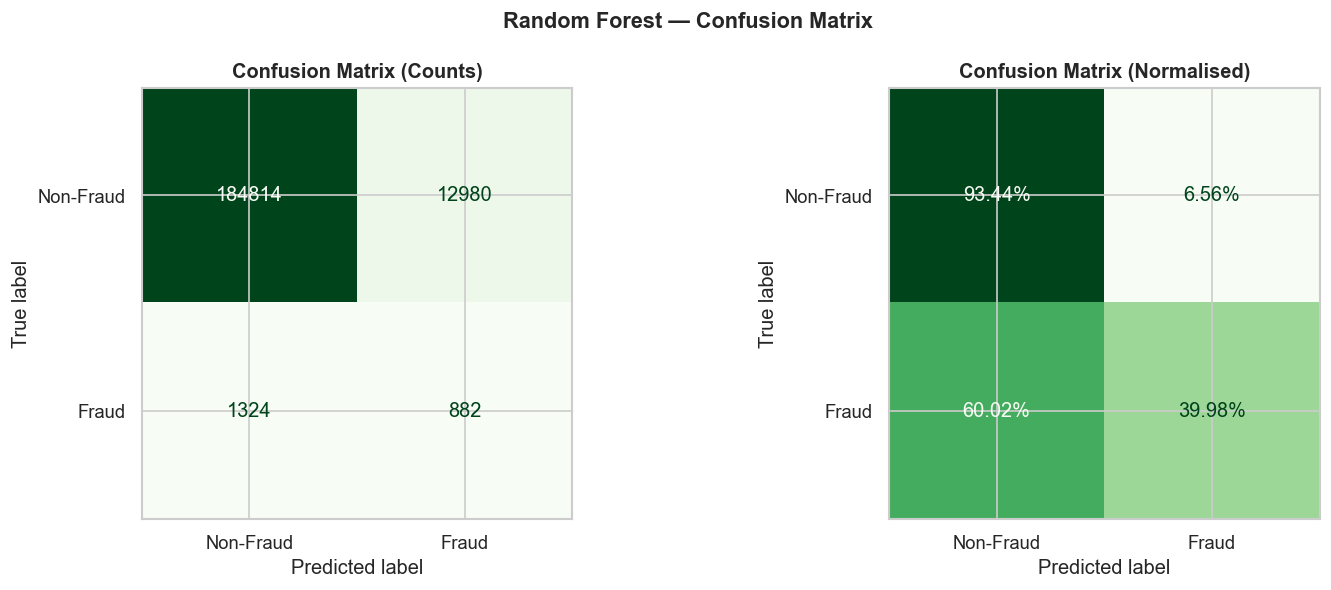

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.suptitle('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', bbox_inches='tight')
plt.show()

The confusion matrix shows that Random Forest correctly classifies most legitimate applications but identifies only approximately 40% of the fraudulent applications. Consequently, a substantial proportion of fraud cases remain False Negatives.

### 4.3 ROC Curve & Precision-Recall Curve

Evaluates Random Forest across different classification thresholds. The ROC curve shows the relationship between the True Positive Rate and False Positive Rate while ROC-AUC summarises the model's overall discriminatory ability.

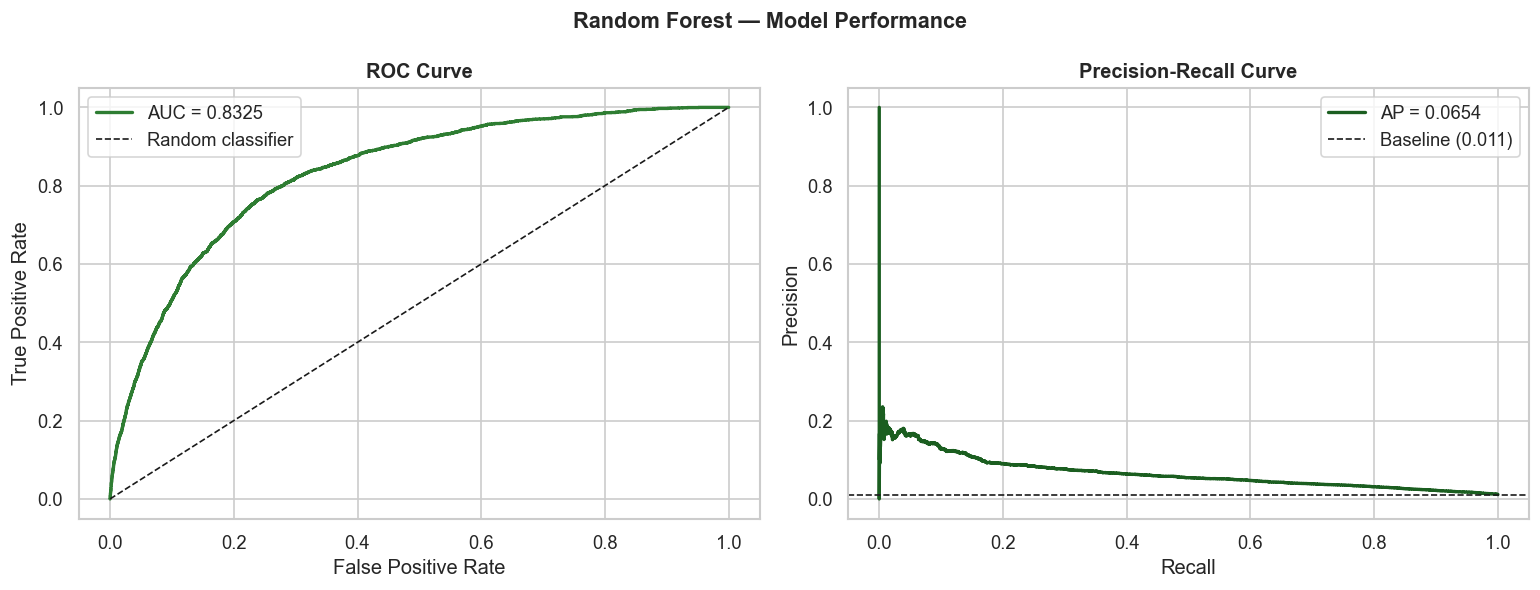

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='#2E7D32', lw=2, label=f'AUC = {auc_score:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)
axes[1].plot(recall, precision, color='#1B5E20', lw=2, label=f'AP = {ap:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('Random Forest — Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curve_rf.png', bbox_inches='tight')
plt.show()

ROC-AUC of 0.8325 indicates that Random Forest has useful discriminatory ability although its performance is not exceptionally strong. The Average Precision of 0.0654 is higher than the underlying fraud prevalence of approximately 1.1% demonstrating that the model performs better than an uninformative classifier.

### 4.4 Feature Importance

Examines the variables that contribute most strongly to the Random Forest predictions using Gini-based feature importance. The fifteen highest-ranked features are displayed to provide an interpretable summary of the fitted model. Feature importance reflects how strongly each variable contributes to reducing impurity across the decision trees. It does not demonstrate a causal relationship between a feature and fraudulent behaviour.

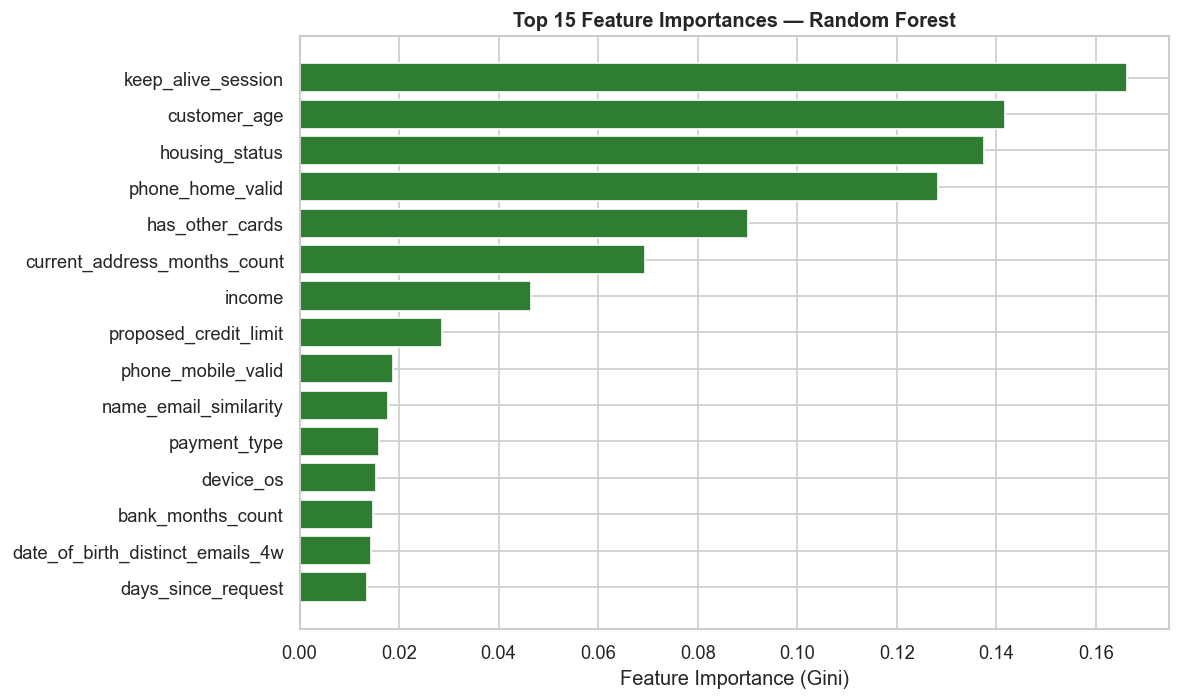

                         Feature  Importance
              keep_alive_session    0.166333
                    customer_age    0.141820
                  housing_status    0.137574
                phone_home_valid    0.128339
                 has_other_cards    0.090164
    current_address_months_count    0.069462
                          income    0.046508
           proposed_credit_limit    0.028690
              phone_mobile_valid    0.018782
           name_email_similarity    0.017766
                    payment_type    0.016043
                       device_os    0.015257
               bank_months_count    0.014768
date_of_birth_distinct_emails_4w    0.014360
              days_since_request    0.013513


In [7]:
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color='#2E7D32', edgecolor='white')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight')
plt.show()
print(feat_imp.to_string(index=False))

keep_alive_session is the most important feature in the baseline Random Forest model followed by customer_age, housing_status, phone_home_valid and has_other_cards. 

### 4.5 Cross-Validation

Assesses the stability of Random Forest using five-fold stratified cross-validation. A 50,000-record sample of the training data is used to reduce computational requirements.

SMOTE is placed inside an imbalanced-learn Pipeline so that oversampling is performed separately within each training fold. This prevents synthetic observations from leaking into the validation folds and provides a more reliable cross-validation estimate.

StratifiedKFold also preserves the fraud distribution within each fold and ROC-AUC is used as the cross-validation scoring metric.

In [8]:
print('Running 5-fold Stratified Cross-Validation...')
print('(using 50,000 sample for speed)')

sample_idx = np.random.choice(len(X_train), size=50000, replace=False)
X_cv = X_train.iloc[sample_idx] if hasattr(X_train, 'iloc') else X_train[sample_idx]
y_cv = y_train.iloc[sample_idx] if hasattr(y_train, 'iloc') else y_train[sample_idx]

cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'\nCV ROC-AUC Scores : {cv_scores.round(4)}')
print(f'Mean              : {cv_scores.mean():.4f}')
print(f'Std               : {cv_scores.std():.4f}')

Running 5-fold Stratified Cross-Validation...
(using 50,000 sample for speed)

CV ROC-AUC Scores : [0.8266 0.8125 0.8343 0.8074 0.8172]
Mean              : 0.8196
Std               : 0.0097


The five-fold cross-validation produces a mean ROC-AUC of 0.8196 with a standard deviation of 0.0097. The relatively small variation between folds suggests that the model's performance is reasonably stable across different subsets of the sampled training data.

The mean cross-validation score is slightly lower than the held-out test ROC-AUC of 0.8325. Because cross-validation is performed using only a 50,000-record sample for computational efficiency, it is primarily used as a stability check rather than as the final performance estimate.

## 5. Compare with Logistic Regression

Provides a preliminary comparison between the baseline Random Forest and the previously trained Logistic Regression model. ROC-AUC, Average Precision, Recall, Precision and F1-score are compared to examine the different strengths and weaknesses of the two algorithms.

The Logistic Regression results are carried over from its individual notebook while the Random Forest metrics are calculated directly from the predictions generated in this notebook.

In [9]:
# Fill in LR results from previous notebook
lr_results = {
    'Model'    : 'Logistic Regression',
    'ROC-AUC'  : 0.8626,
    'Avg Prec' : 0.1220,
    'Recall'   : 0.7697,
    'Precision': 0.0412,   
    'F1'       : 0.0782  
}

rf_results = {
    'Model'    : 'Random Forest',
    'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob), 4),
    'Avg Prec' : round(average_precision_score(y_test, y_pred_prob), 4),
    'Recall'   : round(recall_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'F1'       : round(f1_score(y_test, y_pred), 4)
}

comparison_df = pd.DataFrame([lr_results, rf_results])
print('MODEL COMPARISON')
print('=' * 65)
print(comparison_df.to_string(index=False))
print('=' * 65)

MODEL COMPARISON
              Model  ROC-AUC  Avg Prec  Recall  Precision     F1
Logistic Regression   0.8626    0.1220  0.7697     0.0412 0.0782
      Random Forest   0.8325    0.0654  0.3998     0.0636 0.1098


Logistic Regression achieves higher ROC-AUC (0.8626), Average Precision (0.1220) and Recall (0.7697) than the baseline Random Forest. This indicates stronger overall discrimination and substantially greater sensitivity to fraudulent applications.

Random Forest achieves higher Precision and F1-score but its Recall of 0.3998 indicates that it misses considerably more fraudulent applications. These results demonstrate a trade-off between detecting a larger proportion of fraud cases and limiting false-positive predictions.

## 6. Results Summary

Consolidates the main baseline Random Forest performance measures into a single summary. The reported metrics include Accuracy, fraud-class Precision, Recall, F1-score, ROC-AUC and Average Precision.

The summary provides a concise record of the baseline Random Forest results before hyperparameter optimisation and allows the effect of subsequent tuning to be assessed.

In [10]:
print('=' * 55)
print('  RANDOM FOREST — RESULTS SUMMARY')
print('=' * 55)
print(f'  Accuracy          : {(y_pred==y_test).mean()*100:.2f}%')
print(f'  Precision (Fraud) : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    (Fraud) : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score  (Fraud) : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC           : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'  Avg Precision     : {average_precision_score(y_test, y_pred_prob):.4f}')
print('=' * 55)
print()
print('  ➡️  Next steps:')
print('  - Train XGBoost')
print('  - Final comparison table (LR vs RF vs XGBoost)')
print('=' * 55)

  RANDOM FOREST — RESULTS SUMMARY
  Accuracy          : 92.85%
  Precision (Fraud) : 0.0636
  Recall    (Fraud) : 0.3998
  F1-Score  (Fraud) : 0.1098
  ROC-AUC           : 0.8325
  Avg Precision     : 0.0654

  ➡️  Next steps:
  - Train XGBoost
  - Final comparison table (LR vs RF vs XGBoost)


The baseline Random Forest achieves 92.85% accuracy, a fraud Precision of 0.0636, Recall of 0.3998, F1-score of 0.1098, ROC-AUC of 0.8325 and Average Precision of 0.0654.